Modelo de Regresión Lineal


---



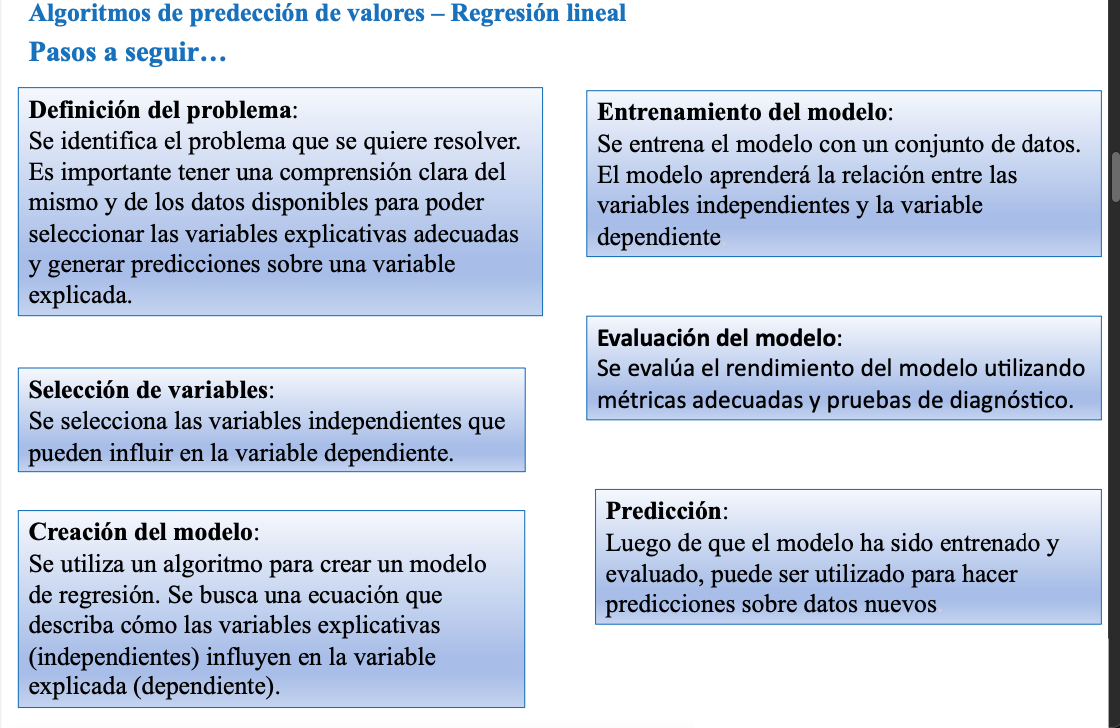

Ejemplo 1

---



Planteo de modelo:


---


* Partimos de un dataset que consta del presupuesto de publicidad a través de diferentes medios y las ventas de productos en n = 200 mercados diferentes.

* Buscamos predecir las ventas (variable explicada) a partir del presupuesto en publicidad televisiva (variable explicativa)

* modelo :

    ventas = B0 + B1 * publicidad televisiva



In [ ]:
#Paso 1
# Importamos las librerías que vamos a utilizar
import numpy as np #para usar arrays y hacer operaciones matemáticas
import pandas as pd #para manipulación y análisis de datos
import seaborn as sb #para graficar
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
from sklearn.linear_model import LinearRegression #para implementar el modelo de regresión lineal
from sklearn.model_selection import train_test_split #para dividir tus datos en conjuntos de entrenamiento y prueba
import matplotlib.pyplot as plt #para graficar
from matplotlib.pyplot import subplots #para armar múltiples gráficos en uno
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF #para calcular el factor de inflación de la varianza
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Cargamos el conjunto de datos
datos=pd.read_csv("Advertising.csv",header=0)
datos

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [ ]:
datos.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


Creamos el modelo


---
Definimos las variables explicativa (TV) y explicada (sales)


In [ ]:
#Creamos un DataFrame con 2 columnas (una que contiene unos "intercepto")
#la otra columna contiene los valores de "TV" del archivo original
X = pd.DataFrame({'intercepto': np.ones(datos.shape[0]),
                  'TV':datos['TV']})
X[:] # vemos las 5 primeras filas del DataFrame creado

,intercepto,TV
0,1.0,230.1
1,1.0,44.5
2,1.0,17.2
3,1.0,151.5
4,1.0,180.8
...,...,...
195,1.0,38.2
196,1.0,94.2
197,1.0,177.0
198,1.0,283.6


In [ ]:
y =datos['sales'] #se deterima la variable dependiente
modelo= sm.OLS(y, X) #ajustamos el modelo, se crea un objeto de modelo lineal con X,Y
resultados = modelo.fit()#ajusta el modelo a los datos y almacena los resultados en la variable"resultados"

In [ ]:
X

,intercepto,TV
0,1.0,230.1
1,1.0,44.5
2,1.0,17.2
3,1.0,151.5
4,1.0,180.8
...,...,...
195,1.0,38.2
196,1.0,94.2
197,1.0,177.0
198,1.0,283.6


In [ ]:
y

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [ ]:
#vemos los resultados
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Thu, 18 Jun 2026   Prob (F-statistic):           1.47e-42
Time:                        00:21:17   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercepto     7.0326      0.458     15.360      0.0

Graficamos....

In [ ]:
#creamos una función
def abline(ax, b, m, *args, **kwargs):
    "Agrega una recta con pendiente m y un intercepto b a un objeto ax"
    xlim = ax.get_xlim() #obtenemos el límite del eje x
    ylim = [m * xlim[0] + b, m * xlim[1] + b] #calcula los límites del eje y
    ax.plot(xlim, ylim, *args, **kwargs)

/tmp/ipykernel_8326/4211323832.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[0],
/tmp/ipykernel_8326/4211323832.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[1],


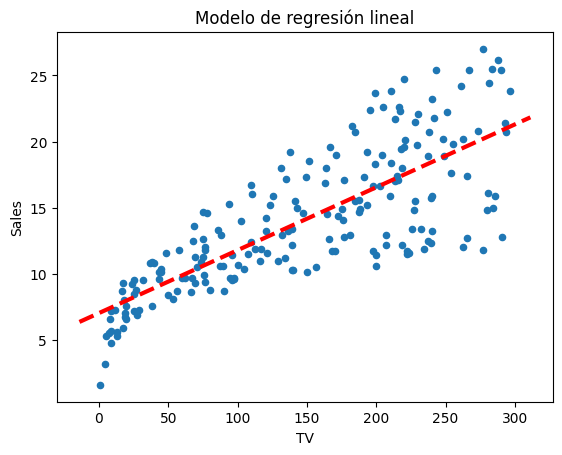

In [ ]:
ax = datos.plot.scatter('TV', 'sales')
abline(ax,
       resultados.params[0],
       resultados.params[1],
       'r--', linewidth=3)
ax.set_title("Modelo de regresión lineal")
ax.set_ylabel("Sales")
ax.set_xlabel("TV")
plt.show()

In [ ]:
#Establecemos una semilla aleatoria para garantizar la reproducibilidad de los resultados
np.random.seed(0)

In [ ]:
# Seleccionamos la variable TV como predictor y la variable sales como variable de respuesta
X = datos["TV"].values.reshape(-1, 1)
Y = datos["sales"]

In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)


In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predecimos el valor medio de las ventas para un valor de TV dado
X_new = np.array([[75], [120], [180], [210]])
y_pred = model.predict(X_new)
print("Predicciones:", y_pred)

Predicciones: [10.74674021 12.8283435  15.60381455 16.99155008]


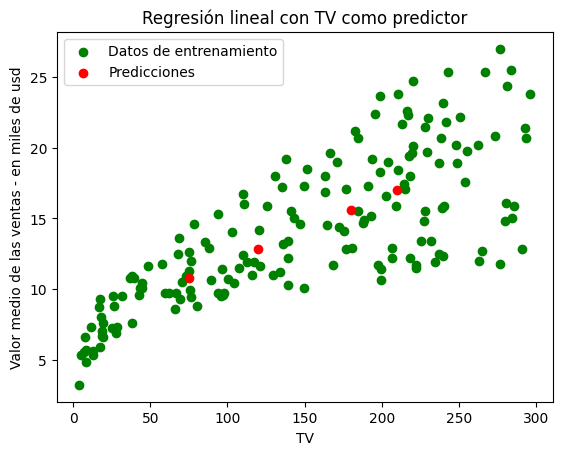

In [ ]:
# Visualizamos los resultados del modelo
plt.scatter(X_train, Y_train, color='green', label='Datos de entrenamiento')
plt.scatter(X_new, y_pred, color='red', label='Predicciones')
plt.xlabel('TV')
plt.ylabel('Valor medio de las ventas - en miles de usd')
plt.title('Regresión lineal con TV como predictor')
plt.legend()
plt.show()


In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.596
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     248.1
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           6.54e-35
Time:                        23:01:44   Log-Likelihood:                -442.29
No. Observations:                 170   AIC:                             888.6
Df Residuals:                     168   BIC:                             894.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.2774      0.503     14.454      0.0

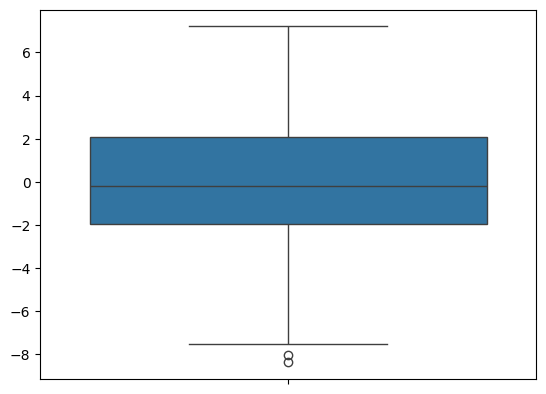

In [ ]:
#vemos la distribución de los residuos con un Boxplot

sb.boxplot(data=resultados.resid)
plt.ticklabel_format(style="plain",axis="y")

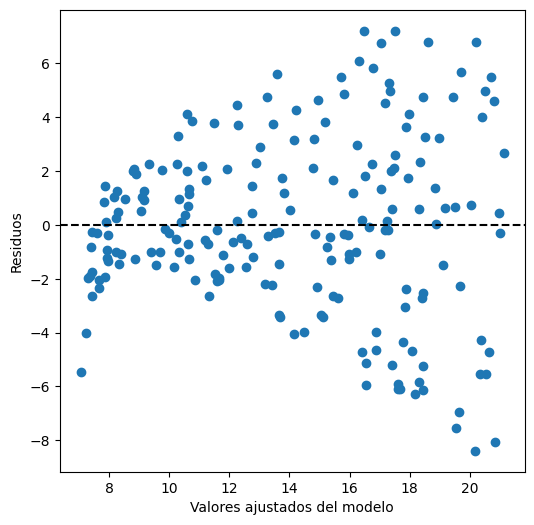

In [ ]:
#evaluamos la relación entre los valores ajustados y los residuos
ax = subplots(figsize=(6,6))[1]
ax.scatter(resultados.fittedvalues , resultados.resid)
ax.set_xlabel('Valores ajustados del modelo')
ax.set_ylabel('Residuos')
ax.axhline(0, c='k', ls='--');

np.int64(101)

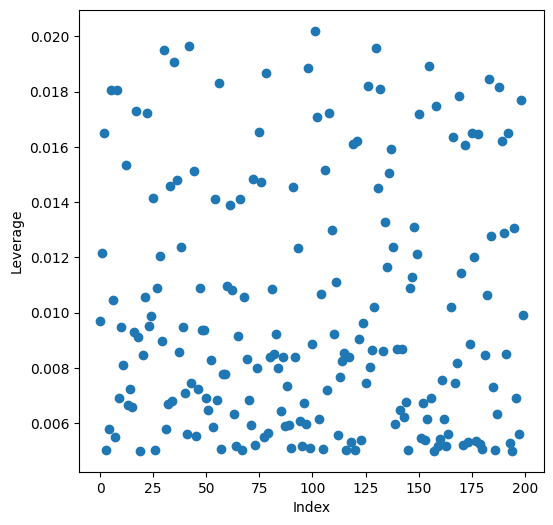

In [ ]:
infl = resultados.get_influence()
ax = subplots(figsize=(6,6))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

Regresión Múltiple

Modelo :  ventas = B0 + B1 * TV + B2 * radio + B3 * periódicos

In [ ]:
# Seleccionamos las variables explicativas 'TV', 'radio' y 'newspaper'
X = datos[['TV', 'radio', 'newspaper']]

# Seleccionamos la variable explicada 'sales'
Y = datos['sales']

In [ ]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [ ]:
Y

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Imprimimos los coeficientes del modelo
print("Coeficientes del modelo:", model.coef_)

Coeficientes del modelo: [0.04416235 0.19900368 0.00116268]


In [ ]:
# Predecimos el valor medio de las ventas
Y_pred = model.predict(X_test)

# Calculamos el error cuadrático medio y el coeficiente de determinación R^2 de las predicciones
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print("Error cuadrático medio:", mse)
print("Coeficiente de determinación R^2:", r2)


Error cuadrático medio: 4.012497522917099
Coeficiente de determinación R^2: 0.8576396745320893


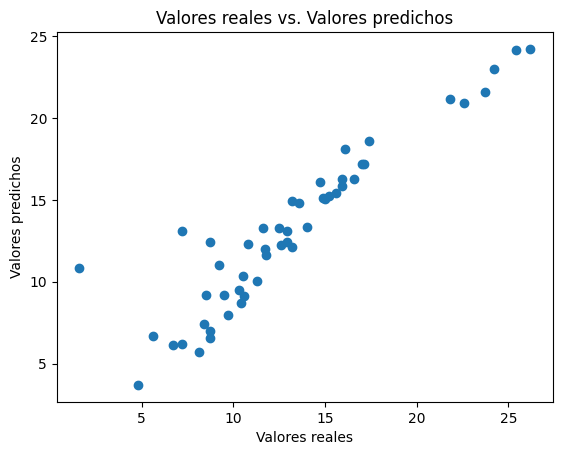

In [ ]:
# Graficamos los valores reales vs. los valores predichos
plt.scatter(Y_test, Y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. Valores predichos")
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     475.9
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           3.89e-75
Time:                        23:01:45   Log-Likelihood:                -279.71
No. Observations:                 150   AIC:                             567.4
Df Residuals:                     146   BIC:                             579.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8926      0.346      8.362      0.0

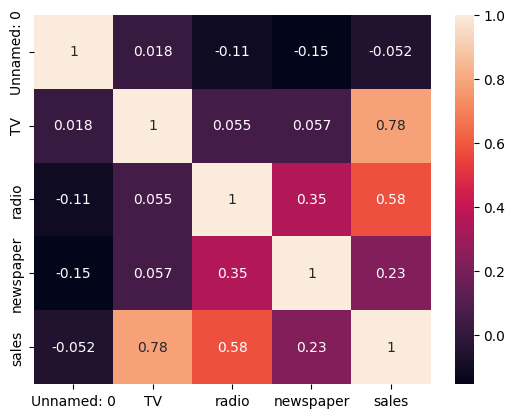

In [ ]:
# Creamos un mapa de calor para visualizar la correlación entre las variables
sb.heatmap(datos.corr(), annot=True)
plt.show()



---
Ejemplo 2

---




In [ ]:

import yfinance as yf


# Descargar datos financieros de Yahoo Finance
def descargar_datos(ticker, inicio, fin):
    """
    Descarga datos históricos de Yahoo Finance
    """
    datos = yf.download(ticker, start=inicio, end=fin)
    return datos

# Ejemplo: Datos de Apple (AAPL) y del S&P 500 (^GSPC) como variable explicativa
inicio = '2020-01-01'
fin = '2023-12-31'

# Descargar datos
print("Descargando datos de AAPL y S&P 500...")
aapl = descargar_datos('AAPL', inicio, fin)
sp500 = descargar_datos('^GSPC', inicio, fin)

# Preparar los datos

datos = pd.DataFrame({
    'AAPL_Close': aapl['Close'].squeeze(),  # convertimos a series
    'SP500_Close': sp500['Close'].squeeze() # convertimos a series
}, index=aapl.index).dropna()

# Calcular retornos diarios
datos['AAPL_Retorno'] = datos['AAPL_Close'].pct_change() * 100
datos['SP500_Retorno'] = datos['SP500_Close'].pct_change() * 100
datos = datos.dropna()

datos

Descargando datos de AAPL y S&P 500...


/tmp/ipykernel_8326/4088709800.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_8326/4088709800.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed


,AAPL_Close,SP500_Close,AAPL_Retorno,SP500_Retorno
Date,,,,
2020-01-03,71.630638,3234.850098,-0.972213,-0.705987
2020-01-06,72.201431,3246.280029,0.796856,0.353337
2020-01-07,71.861862,3237.179932,-0.470308,-0.280324
2020-01-08,73.017830,3253.050049,1.608597,0.490245
2020-01-09,74.568802,3274.699951,2.124100,0.665526
...,...,...,...,...
2023-12-22,191.433121,4754.629883,-0.554727,0.166006
2023-12-26,190.889252,4774.750000,-0.284104,0.423169
2023-12-27,190.988113,4781.580078,0.051790,0.143046


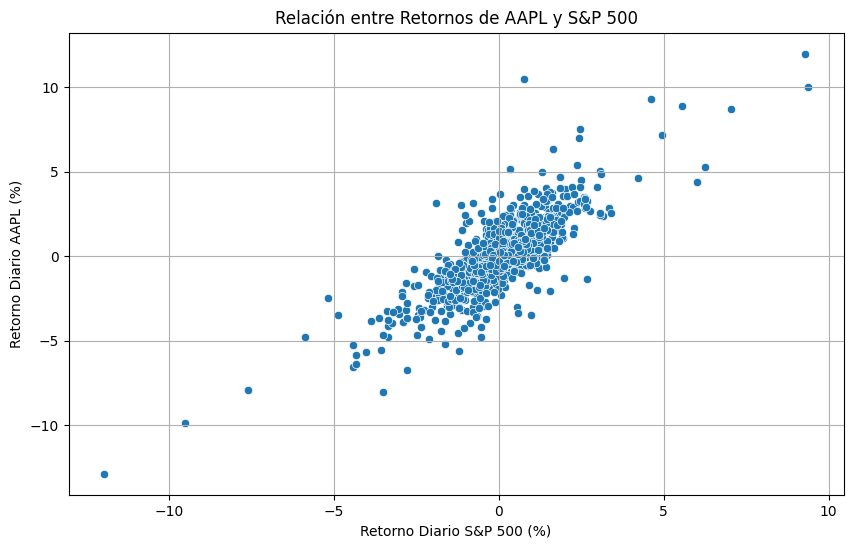

In [ ]:
# Visualizamos la relación entre los retornos
plt.figure(figsize=(10, 6))
sb.scatterplot(x='SP500_Retorno', y='AAPL_Retorno', data=datos)
plt.title('Relación entre Retornos de AAPL y S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.grid(True)
plt.show()

In [ ]:
# Preparar datos para el modelo
X = datos[['SP500_Retorno']]  # Variable independiente (retorno del mercado)
y = datos['AAPL_Retorno']     # Variable dependiente (retorno de AAPL)

In [ ]:
# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predecir con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nResultados del Modelo de Regresión Lineal:")
print(f"Coeficiente (Beta1): {modelo.coef_[0]:.4f}")
print(f"Intercepto (Beta0): {modelo.intercept_:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Resultados del Modelo de Regresión Lineal:
Coeficiente (Beta1): 1.2055
Intercepto (Beta0): 0.0775
Error Cuadrático Medio (MSE): 1.5980
Coeficiente de Determinación (R²): 0.6595


In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
import statsmodels.api as sm #para ajustar el modelo y hacer pruebas estadíticas
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:           AAPL_Retorno   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.666
Method:                 Least Squares   F-statistic:                     1603.
Date:                Wed, 17 Jun 2026   Prob (F-statistic):          2.02e-193
Time:                        23:01:49   Log-Likelihood:                -1295.9
No. Observations:                 804   AIC:                             2596.
Df Residuals:                     802   BIC:                             2605.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0775      0.043      1.810

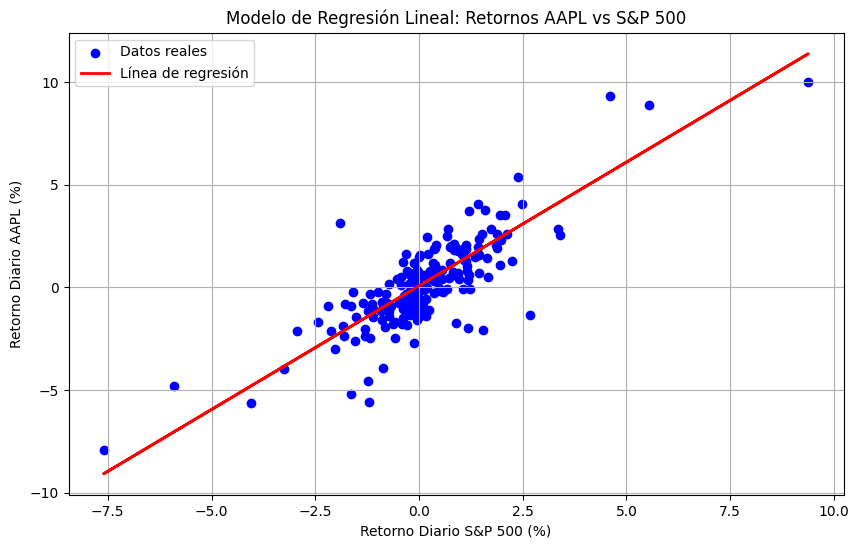

In [ ]:
# Visualizar resultados
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Datos reales')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de regresión')
plt.title('Modelo de Regresión Lineal: Retornos AAPL vs S&P 500')
plt.xlabel('Retorno Diario S&P 500 (%)')
plt.ylabel('Retorno Diario AAPL (%)')
plt.legend()
plt.grid(True)
plt.show()

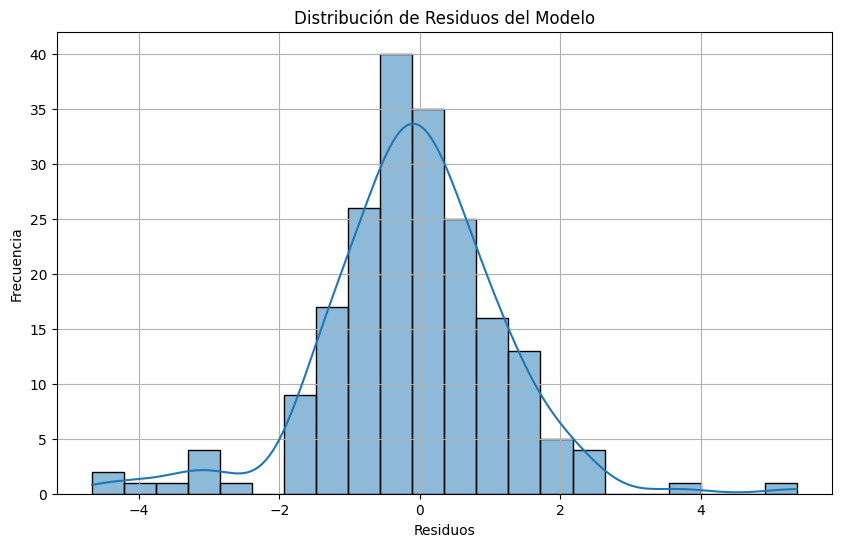

In [ ]:
# Análisis de residuos
residuos = y_test - y_pred
plt.figure(figsize=(10, 6))
sb.histplot(residuos, kde=True)
plt.title('Distribución de Residuos del Modelo')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

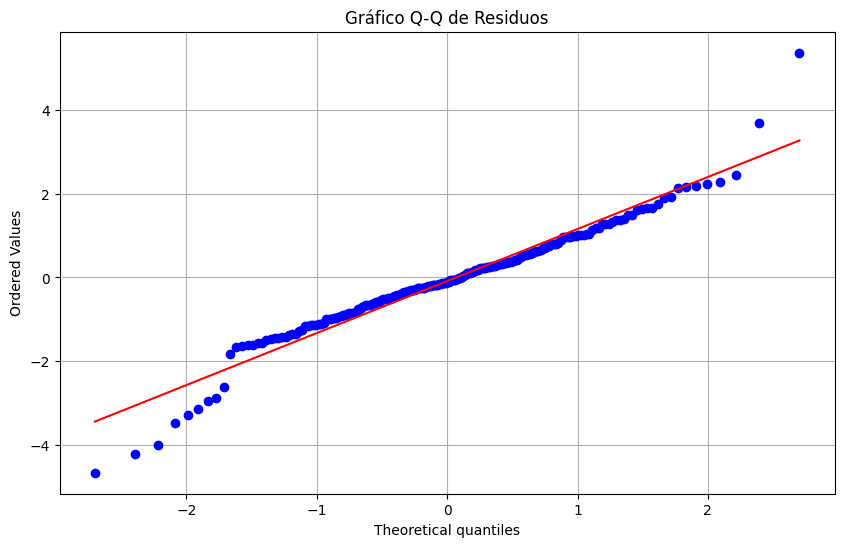

In [ ]:
# Gráfico Q-Q para normalidad de residuos
import scipy.stats as stats
plt.figure(figsize=(10, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')
plt.grid(True)
plt.show()

In [ ]:
#REGRESIÓN MÚLTIPLE

def descargar_datos(tickers, inicio, fin):
    """
    Descarga datos históricos de múltiples activos
    """
    datos = yf.download(tickers, start=inicio, end=fin)['Close']
    return datos

# Definir período de tiempo y activos
inicio = '2023-01-01'
fin = '2025-12-31'
activos = ['AAPL', '^GSPC', '^TNX', 'DX-Y.NYB']  # Apple, S&P 500, Yield 10y, Dólar Index

# Descargar datos
print("Descargando datos financieros...")
datos = descargar_datos(activos, inicio, fin)
datos.columns = ['AAPL', 'SP500', 'Yield_10y', 'Dolar_Index']  # Renombrar columnas

# Calcular retornos diarios y limpiar datos
retornos = datos.pct_change().dropna()
retornos *= 100  # Convertir a porcentaje
retornos #visualizamos el dataframe que vamos a usar

/tmp/ipykernel_8326/1685393880.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=inicio, end=fin)['Close']
[                       0%                       ]

Descargando datos financieros...


[*********************100%***********************]  4 of 4 completed
/tmp/ipykernel_8326/1685393880.py:21: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = datos.pct_change().dropna()


,AAPL,SP500,Yield_10y,Dolar_Index
Date,,,,
2023-01-04,1.031428,-0.258321,0.753897,-2.214602
2023-01-05,-1.060472,0.757795,-1.164553,0.296574
2023-01-06,3.679393,-1.104345,2.284078,-4.059140
2023-01-09,0.408907,-0.847129,-0.076763,-1.456992
2023-01-10,0.445627,0.233008,0.697823,2.957068
...,...,...,...,...
2025-12-23,0.512971,-0.356088,0.455039,0.000000
2025-12-24,0.532378,0.040842,0.322148,-0.791557
2025-12-26,-0.149739,0.040818,-0.030436,0.000000


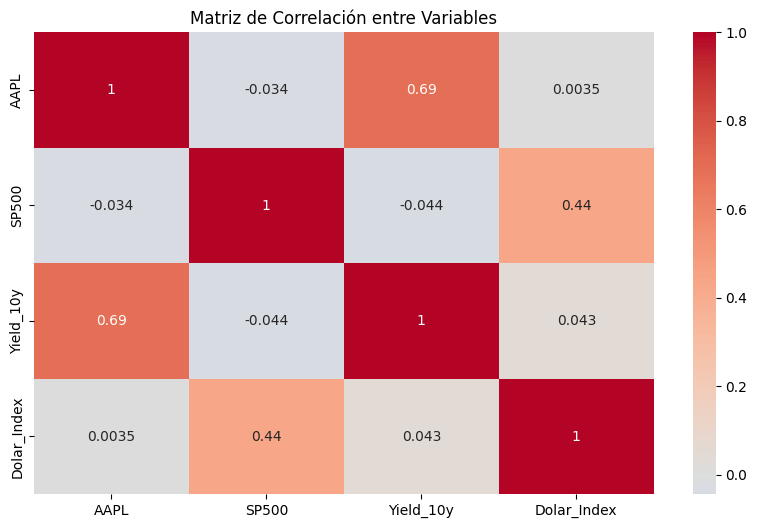

In [ ]:
# Visualizamos las correlaciones
plt.figure(figsize=(10, 6))
sb.heatmap(retornos.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación entre Variables')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Preparamos las variables para el modelo
X = retornos[['SP500', 'Yield_10y', 'Dolar_Index']]  # Variables independientes
y = retornos['AAPL']  # Variable dependiente

# Estandarizamos variables (importante para regresión múltiple)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# Calcular VIF para detectar multicolinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("\nFactores de Inflación de Varianza (VIF):")
print(vif_data)


Factores de Inflación de Varianza (VIF):
      Variable       VIF
0        SP500  1.239872
1    Yield_10y  1.007168
2  Dolar_Index  1.239791


In [ ]:
# Dividimos datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Creamos y entrenamos modelo de regresión múltiple
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predecimos con el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluamos el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Mostrar resultados
print("\nResultados del Modelo de Regresión Múltiple:")
print(f"Intercepto (Beta0): {modelo.intercept_:.4f}")
for i, col in enumerate(X.columns):
    print(f"Coeficiente para {col}: {modelo.coef_[i]:.4f}")
print(f"\nError Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Resultados del Modelo de Regresión Múltiple:
Intercepto (Beta0): 0.0729
Coeficiente para SP500: -0.0362
Coeficiente para Yield_10y: 1.1174
Coeficiente para Dolar_Index: 0.0189

Error Cuadrático Medio (MSE): 1.6807
Coeficiente de Determinación (R²): 0.3119


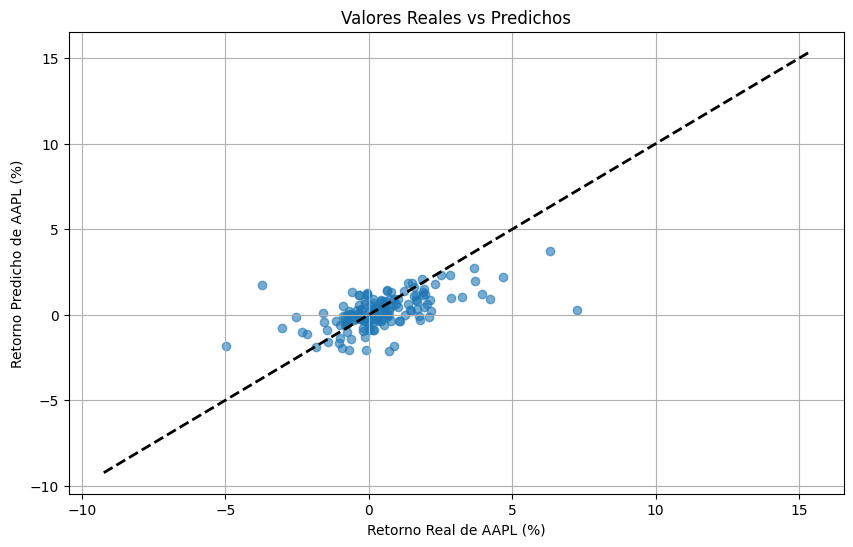

In [ ]:
# Gráfico de valores reales vs predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Retorno Real de AAPL (%)')
plt.ylabel('Retorno Predicho de AAPL (%)')
plt.title('Valores Reales vs Predichos')
plt.grid(True)
plt.show()

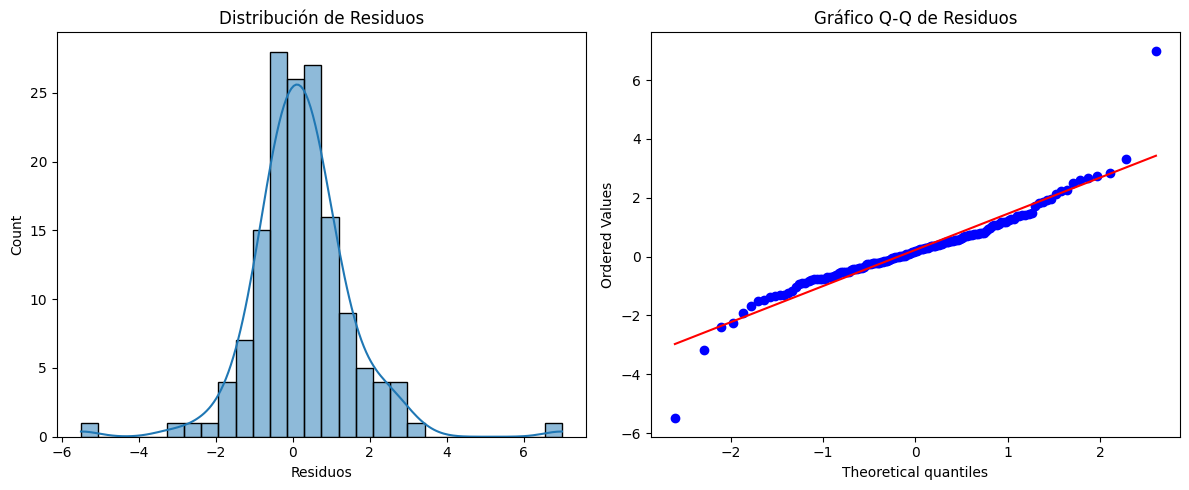

In [ ]:
# Análisis de residuos
import scipy.stats as stats
residuos = y_test - y_pred
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sb.histplot(residuos, kde=True)
plt.title('Distribución de Residuos')
plt.xlabel('Residuos')

plt.subplot(1, 2, 2)
stats.probplot(residuos, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')

plt.tight_layout()
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
import statsmodels.api as sm
import pandas as pd

# Reseteamos los indices de  y_train and X_train
y_train = y_train.reset_index(drop=True)
X_train = X_train.reset_index(drop=True)


if not isinstance(X_train, pd.DataFrame):
    X_train = pd.DataFrame(X_train)

X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     203.0
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           9.84e-91
Time:                        23:01:51   Log-Likelihood:                -928.35
No. Observations:                 601   AIC:                             1865.
Df Residuals:                     597   BIC:                             1882.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0729      0.046      1.568      

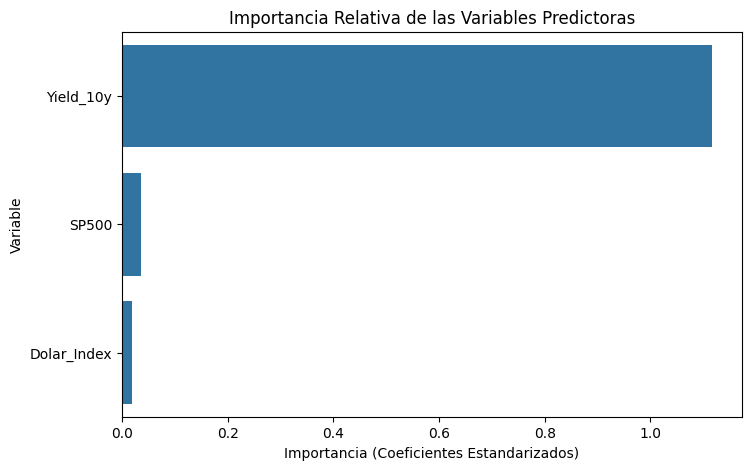

In [ ]:
# Importancia de variables (usando valores absolutos de coeficientes estandarizados)
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': np.abs(modelo.coef_)
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(8, 5))
sb.barplot(x='Importancia', y='Variable', data=importancia)
plt.title('Importancia Relativa de las Variables Predictoras')
plt.xlabel('Importancia (Coeficientes Estandarizados)')
plt.show()



---
Ejemplo 3

---




El dataset Carseats contiene datos simulados sobre las ventas de asientos para niños en 400 tiendas diferentes. Este conjunto de datos incluye las siguientes variables:

Sales: Ventas unitarias (en miles) en cada ubicación.

CompPrice: Precio cobrado por el competidor en cada ubicación.

Income: Nivel de ingresos de la comunidad (en miles de dólares).

Advertising: Presupuesto de publicidad local para la empresa en cada ubicación (en miles de dólares).

Population: Tamaño de la población en la región (en miles).

Price: Precio que la empresa cobra por los asientos para niños en cada sitio.

ShelveLoc: Calidad de la ubicación en los estantes para los asientos (con niveles: Malo, Bueno y Medio).

Age: Edad promedio de la población local.

Education: Nivel educativo en cada ubicación.

Urban: Indicador de si la tienda está en una zona urbana o rural.

US: Indicador de si la tienda está en los EE. UU. o no.

In [ ]:
#Cargamos el conjunto de datos
url = 'https://raw.githubusercontent.com/selva86/datasets/master/Carseats.csv'
datos = pd.read_csv(url)
datos

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [ ]:
#Creamos el modelo
#definimos la variable explicativa (precio)y explicada (ventas)

#Creamos un DataFrame con 2 columnas (una que contiene unos "intercepto")
#la otra columna contiene los valores de "Price" del archivo original
X = pd.DataFrame({'intercepto': np.ones(datos.shape[0]),
                  'Price':datos['Price']})
X

,intercepto,Price
0,1.0,120
1,1.0,83
2,1.0,80
3,1.0,97
4,1.0,128
...,...,...
395,1.0,128
396,1.0,120
397,1.0,159
398,1.0,95


In [ ]:
#se deterima la variable dependiente
y =datos['Sales']
#ajustamos el modelo, se crea un objeto de modelo lineal con X,Y
modelo= sm.OLS(y, X)
#ajusta el modelo a los datos y almacena los resultados en la variable"resultados"
resultados = modelo.fit()

#vemos los resultados
print(resultados.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     98.25
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           7.62e-21
Time:                        23:01:52   Log-Likelihood:                -938.23
No. Observations:                 400   AIC:                             1880.
Df Residuals:                     398   BIC:                             1888.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercepto    13.6419      0.633     21.558      0.0

/tmp/ipykernel_8326/3809437539.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[0],
/tmp/ipykernel_8326/3809437539.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  resultados.params[1],


Text(0.5, 0, 'Precio')

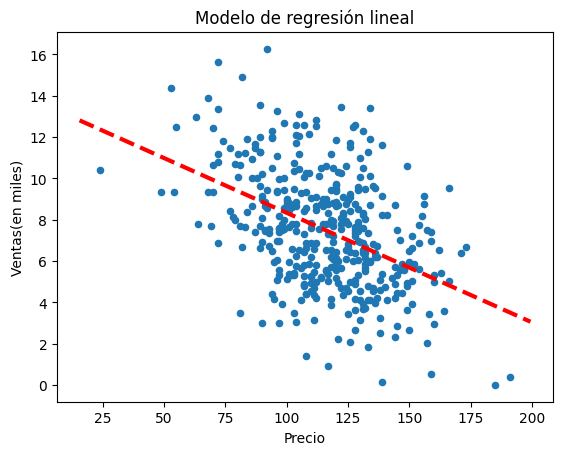

In [ ]:
#Graficamos:

#creamos una función
def abline(ax, b, m, *args, **kwargs):
    "Agrega una recta con pendiente m y un intercepto b a un objeto ax"
    xlim = ax.get_xlim() #obtenemos el límite del eje x
    ylim = [m * xlim[0] + b, m * xlim[1] + b] #calcula los límites del eje y
    ax.plot(xlim, ylim, *args, **kwargs)

ax = datos.plot.scatter('Price', 'Sales')
abline(ax,
       resultados.params[0],
       resultados.params[1],
       'r--', linewidth=3)
ax.set_title("Modelo de regresión lineal")
ax.set_ylabel("Ventas(en miles)")
ax.set_xlabel("Precio")

In [ ]:
#Establecemos una semilla aleatoria para garantizar la reproducibilidad de los resultados
np.random.seed(42)

In [ ]:
# Seleccionamos la variable Price como predictor y la variable Sales como variable de respuesta
X = datos["Price"].values.reshape(-1, 1)
Y = datos["Sales"]

In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25)

In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Predecimos el valor medio de las ventas para un valor de Precio dado
X_new = np.array([[50], [100], [150], [200], [250]])
y_pred = model.predict(X_new)
print("Predicciones:", y_pred)

Predicciones: [10.90665313  8.26750149  5.62834985  2.9891982   0.35004656]


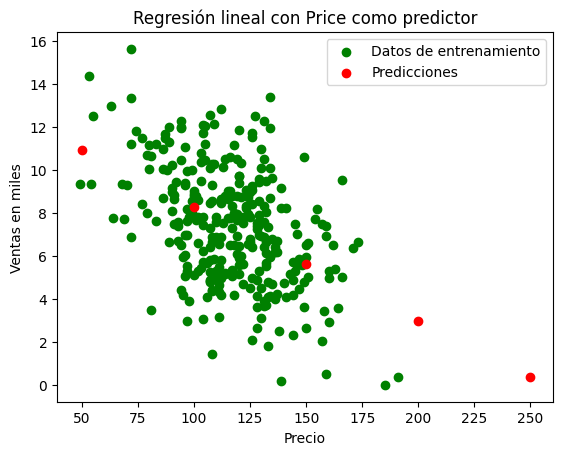

In [ ]:
# Visualizamos los resultados del modelo
plt.scatter(X_train, Y_train, color='green', label='Datos de entrenamiento')
plt.scatter(X_new, y_pred, color='red', label='Predicciones')
plt.xlabel('Precio')
plt.ylabel('Ventas en miles')
plt.title('Regresión lineal con Price como predictor')
plt.legend()
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     78.57
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           7.18e-17
Time:                        23:01:52   Log-Likelihood:                -692.75
No. Observations:                 300   AIC:                             1390.
Df Residuals:                     298   BIC:                             1397.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.5458      0.708     19.136      0.0

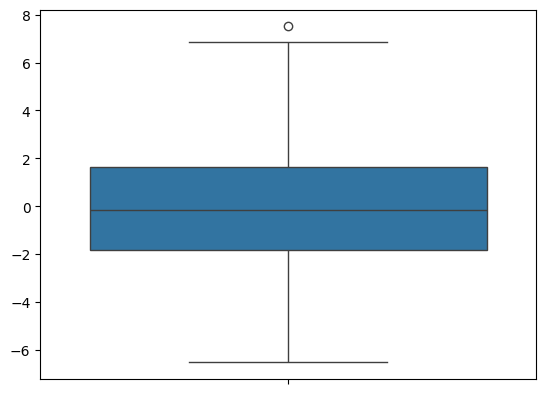

In [ ]:
#vemos la distribución de los residuos con un Boxplot

sb.boxplot(data=resultados.resid)
plt.ticklabel_format(style="plain",axis="y")

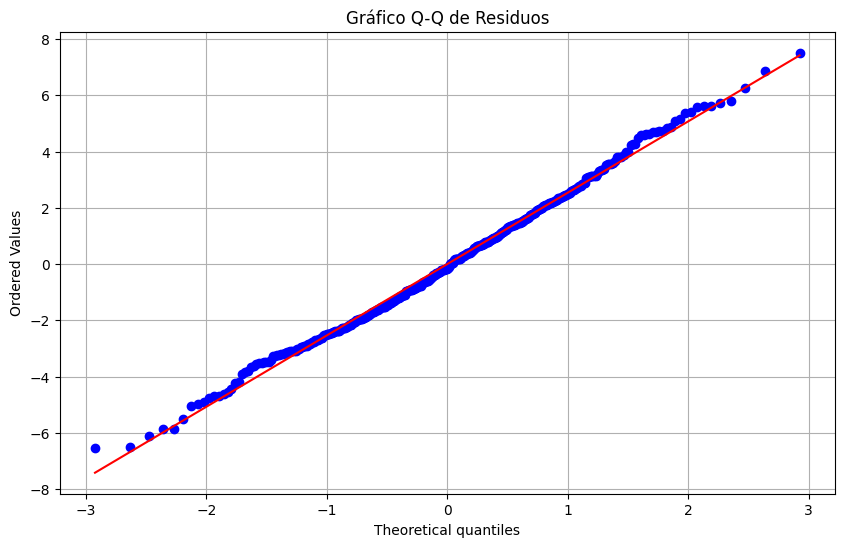

In [ ]:
# Gráfico Q-Q para normalidad de residuos
import scipy.stats as stats
plt.figure(figsize=(10, 6))
stats.probplot(resultados.resid, dist="norm", plot=plt)
plt.title('Gráfico Q-Q de Residuos')
plt.grid(True)
plt.show()

In [ ]:
#MODELO DE REGRESIÓN MÚLTIPLE

# Seleccionamos las variables explicativas 'Price', 'Advertising', 'Income'y 'Population'
X = datos[['Price', 'Advertising', 'Income', 'Population']]

# Seleccionamos la variable explicada 'sales'
Y = datos['Sales']

In [ ]:
# Dividimos el conjunto de datos en un conjunto de entrenamiento y uno de prueba
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

In [ ]:
# Ajustamos un modelo de regresión lineal al conjunto de entrenamiento
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [ ]:
# Imprimimos los coeficientes del modelo
print("Coeficientes del modelo:", model.coef_)

Coeficientes del modelo: [-0.05268799  0.12301694  0.00599227  0.00032507]


In [ ]:
# Predecimos el valor medio de las ventas
Y_pred = model.predict(X_test)
Y_pred

array([ 9.0909035 ,  6.51480686,  7.43373648,  6.37496984,  6.96982148,
        6.03928811,  9.13008538,  9.06192804,  8.49175415,  5.9133342 ,
        6.4342246 ,  8.20773813,  8.33095338,  6.54610154,  6.78615463,
       11.40490644,  5.25703248, 10.20108601,  6.27334018,  7.4775741 ,
        9.47455103,  5.97513346,  6.10795511,  6.95154979,  7.80560792,
        6.44416629,  8.29690359,  8.21114652,  7.62762479,  5.70557431,
        8.30820463,  8.49343507,  6.83549848,  6.6357776 ,  8.43293816,
        6.01884666,  7.1923115 ,  8.37825438,  7.07052959,  5.70497235,
        7.42602762,  5.25383662, 10.42363766,  8.17637496,  6.01926873,
        8.48008127,  7.97499777,  7.97625653,  6.15218938,  6.73143304,
       10.82640785,  8.0953965 ,  7.12346402,  9.43938385,  7.20265341,
        5.3832284 ,  7.12835054,  8.70256124,  8.26717468,  6.08200874,
        6.66123028,  7.897136  ,  9.51397128,  5.06389678,  6.61685409,
        7.73986308,  8.25295171,  7.07859966,  7.72804418,  8.55

In [ ]:
# Calculamos el error cuadrático medio y el coeficiente de determinación R^2 de las predicciones
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print("Error cuadrático medio:", mse)
print("Coeficiente de determinación R^2:", r2)

Error cuadrático medio: 6.964134463827586
Coeficiente de determinación R^2: 0.2441206769051294


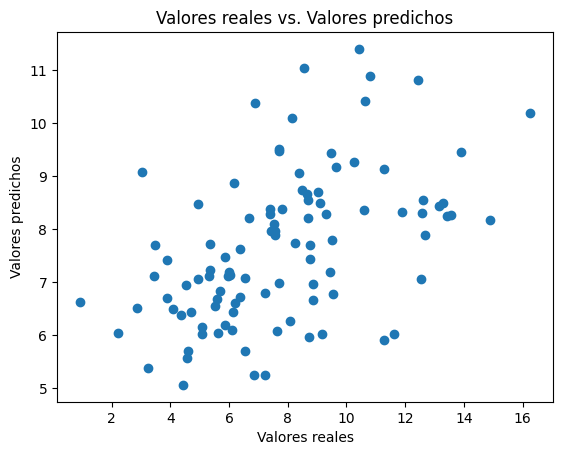

In [ ]:
# Graficamos los valores reales vs. los valores predichos
plt.scatter(Y_test, Y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. Valores predichos")
plt.show()

In [ ]:
# Ajustamos un modelo OLS con statsmodels para obtener los valores p y la estadística t
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(Y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     32.29
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           2.53e-22
Time:                        23:01:53   Log-Likelihood:                -673.39
No. Observations:                 300   AIC:                             1357.
Df Residuals:                     295   BIC:                             1375.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          12.2478      0.825     14.845      